# Random Forest (4/6) — The Out-of-Bag (OOB) Score

### The idea in one sentence
> Every tree in a forest **never sees about 37% of the training rows**. Those rows are a free test set for that
> tree, so the forest can **validate itself without a separate validation set**.

### In this notebook
1. What out-of-bag rows are, and why it is about **37%**
2. `oob_score_` vs test accuracy on the **heart disease** data
3. Compute the OOB score **by hand** and check it matches scikit-learn
4. OOB score vs number of trees
5. How reliable is OOB? (OOB vs cross-validation vs test, over several seeds)

> 📖 Theory: [`theory.md`](theory.md) §4 and §11 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. What are out-of-bag rows?

A bootstrap sample draws $n$ rows **with replacement** from $n$ rows. Some rows are picked twice or more, and some
are **never picked**. Those never-picked rows are the tree's **out-of-bag (OOB)** rows.

The chance that one particular row is *never* picked in $n$ draws:

$$P(\text{row is OOB}) = \left(1 - \frac{1}{n}\right)^n \;\longrightarrow\; e^{-1} \approx 0.368 \quad (n \text{ large})$$

So each tree sees about **63.2%** of the distinct rows and leaves out about **36.8%**. Let us check with a simulation.

> ✍️ **Core code: learn this.** Draw one bootstrap sample of 242 row numbers and count what is left out.

In [2]:
rng = np.random.default_rng(0)
n = 242                                            # size of our heart training set (below)
sample = rng.integers(0, n, size=n)                # n draws WITH replacement
oob_rows = np.setdiff1d(np.arange(n), sample)      # rows never drawn

print("distinct rows in the sample:", len(np.unique(sample)), f"({len(np.unique(sample)) / n:.1%})")
print("out-of-bag rows            :", len(oob_rows), f"({len(oob_rows) / n:.1%})")
print("formula (1 - 1/n)^n        :", round((1 - 1 / n) ** n, 4), "| e^-1 =", round(np.exp(-1), 4))

distinct rows in the sample: 152 (62.8%)
out-of-bag rows            : 90 (37.2%)
formula (1 - 1/n)^n        : 0.3671 | e^-1 = 0.3679


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

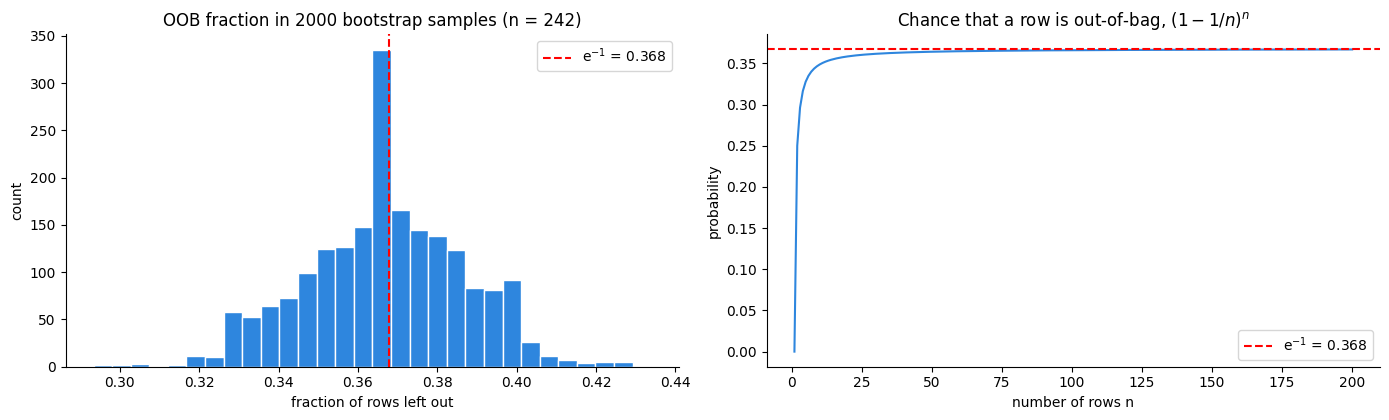

In [3]:
fractions = [1 - len(np.unique(rng.integers(0, n, size=n))) / n for _ in range(2000)]
sizes = np.arange(1, 201)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].hist(fractions, bins=30, color='#2e86de', edgecolor='white')
axes[0].axvline(np.exp(-1), color='red', ls='--', label='e$^{-1}$ = 0.368')
axes[0].set_title(f'OOB fraction in 2000 bootstrap samples (n = {n})')
axes[0].set_xlabel('fraction of rows left out')
axes[0].set_ylabel('count')
axes[0].legend()
axes[1].plot(sizes, (1 - 1 / sizes) ** sizes, color='#2e86de')
axes[1].axhline(np.exp(-1), color='red', ls='--', label='e$^{-1}$ = 0.368')
axes[1].set_title('Chance that a row is out-of-bag, $(1-1/n)^n$')
axes[1].set_xlabel('number of rows n')
axes[1].set_ylabel('probability')
axes[1].legend()
plt.tight_layout()
plt.show()

- Left: in every bootstrap sample about 37% of the rows are out-of-bag (with small random variation).
- Right: the chance quickly settles at 0.368 once there are more than a few dozen rows.

## 2. `oob_score_` vs test accuracy on the heart data

**Heart disease data (UCI):** 303 patients, 13 medical features (age, sex, chest-pain type, cholesterol, max heart
rate, …) and `target` = 1 if the patient has heart disease.

In [4]:
df = pd.read_csv('heart.csv')
print(df.shape)
print("target counts:", df['target'].value_counts().to_dict())
df.head()

(303, 14)
target counts: {1: 165, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


> ✍️ **Core code: learn this.** Hold out 20% as a real test set. Turn on `oob_score=True` when creating the forest.

In [5]:
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

print("\nOOB score (from the training data only):", round(rf.oob_score_, 3))
print("Test accuracy (61 unseen patients)     :", round(accuracy_score(y_test, rf.predict(X_test)), 3))

train: (242, 13) | test: (61, 13)



OOB score (from the training data only): 0.835
Test accuracy (61 unseen patients)     : 0.836


The OOB score was computed **only from the training set**, yet it is almost identical to the accuracy on the
held-out test set (0.835 vs 0.836). It is a good estimate of how the forest does on new data, at almost no extra
cost. (Such a close match is partly luck; Section 5 shows how much each estimate wobbles.)

## 3. The OOB score by hand

How does scikit-learn compute it? For **each training row**:
1. find the trees for which this row was out-of-bag (the trees that never saw it);
2. average **only those trees'** predicted probabilities and take the most likely class;
3. compare with the true label.

The OOB score is the accuracy over all training rows. `rf.estimators_samples_` gives the rows each tree was trained on.

> ✍️ **Core code: learn this.** Re-compute `oob_score_` ourselves.

In [6]:
n_train = len(X_train)
proba_sum = np.zeros((n_train, 2))      # summed class probabilities from the trees that did NOT see the row
n_oob_trees = np.zeros(n_train)         # how many trees each row was out-of-bag for

for tree, rows_seen in zip(rf.estimators_, rf.estimators_samples_):
    oob = np.ones(n_train, dtype=bool)
    oob[rows_seen] = False                                  # rows this tree never saw
    proba_sum[oob] += tree.predict_proba(X_train.values[oob])
    n_oob_trees[oob] += 1

oob_pred = proba_sum.argmax(axis=1)
print("OOB score by hand  :", round(accuracy_score(y_train, oob_pred), 4))
print("sklearn oob_score_ :", round(rf.oob_score_, 4))
print(f"\nOn average a row was out-of-bag for {n_oob_trees.mean():.1f} of the 100 trees "
      f"(min {n_oob_trees.min():.0f}, max {n_oob_trees.max():.0f})")

OOB score by hand  : 0.8347
sklearn oob_score_ : 0.8347

On average a row was out-of-bag for 36.7 of the 100 trees (min 24, max 47)


Identical. Each row is judged by a "mini forest" of about 37 trees that never saw it, so the score is honest:
no tree is ever asked about a row it memorised.

> ℹ️ `rf.oob_decision_function_` stores those averaged OOB probabilities for every training row.

In [7]:
pd.DataFrame(rf.oob_decision_function_, columns=['P(no disease)', 'P(disease)']).head().round(2)

,P(no disease),P(disease)
0,0.03,0.97
1,0.70,0.30
2,0.39,0.61
3,0.13,0.87
4,0.85,0.15


## 4. OOB score vs number of trees

With very few trees, some rows are out-of-bag for no tree at all (scikit-learn then warns that they have no OOB
score). So we start at 15 trees.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

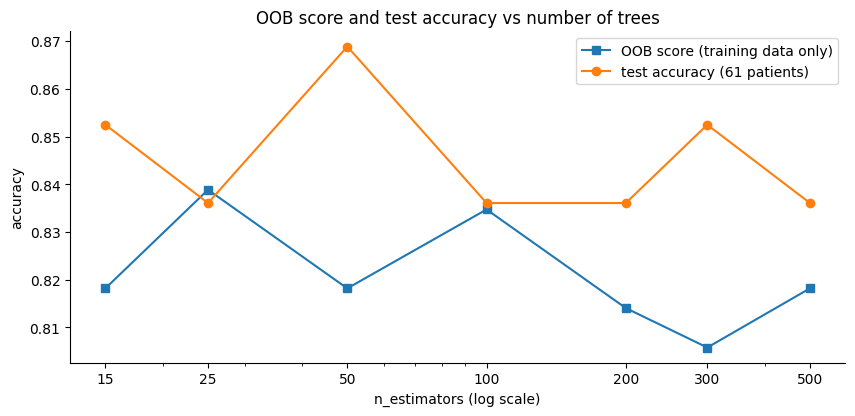

 n_estimators   OOB  test
           15 0.818 0.852
           25 0.839 0.836
           50 0.818 0.869
          100 0.835 0.836
          200 0.814 0.836
          300 0.806 0.852
          500 0.818 0.836


In [8]:
ns = [15, 25, 50, 100, 200, 300, 500]
oob_scores, test_scores = [], []
for k in ns:
    m = RandomForestClassifier(n_estimators=k, oob_score=True, random_state=42, n_jobs=-1).fit(X_train, y_train)
    oob_scores.append(m.oob_score_)
    test_scores.append(m.score(X_test, y_test))

plt.figure(figsize=(10, 4.3))
plt.plot(ns, oob_scores, 's-', label='OOB score (training data only)')
plt.plot(ns, test_scores, 'o-', label='test accuracy (61 patients)')
plt.xscale('log')
plt.xticks(ns, ns)
plt.xlabel('n_estimators (log scale)')
plt.ylabel('accuracy')
plt.title('OOB score and test accuracy vs number of trees')
plt.legend()
plt.show()
print(pd.DataFrame({'n_estimators': ns, 'OOB': oob_scores, 'test': test_scores}).round(3).to_string(index=False))

Both lines wobble by a few points and show **no clear trend** beyond about 25 trees: on only 242 training
and 61 test patients, one or two rows more or less change the score by 0.4 (OOB) or 1.6 (test) points. Here the
OOB score sits a little below the test accuracy for most settings; Section 5 shows that this gap is mostly noise
of the small test set, not a flaw of OOB.

## 5. How reliable is the OOB score?

One split and one forest can be lucky or unlucky. Repeat with **10 different random seeds** (different
train/test splits and forests) and compare three estimates of accuracy:
- **OOB score** (free, from the training set);
- **5-fold cross-validation** on the training set (costs 5 extra fits);
- **test accuracy** on the 61 held-out patients.

> ✍️ **Core code: learn this.** Compare the three estimates over 10 seeds.

In [9]:
rows = []
for seed in range(10):
    a, b, c, d = train_test_split(X, y, test_size=0.2, random_state=seed)
    m = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=seed, n_jobs=-1).fit(a, c)
    cv = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1), a, c, cv=5).mean()
    rows.append({'seed': seed, 'OOB': m.oob_score_, '5-fold CV': cv, 'test': m.score(b, d)})

est = pd.DataFrame(rows).set_index('seed')
print(est.round(3).T.to_string())
print("\nmean:", est.mean().round(3).to_dict())
print("std :", est.std().round(3).to_dict())

seed           0      1      2      3      4      5      6      7      8      9
OOB        0.826  0.860  0.810  0.810  0.806  0.777  0.822  0.835  0.802  0.826
5-fold CV  0.823  0.856  0.802  0.802  0.806  0.781  0.843  0.847  0.798  0.801
test       0.836  0.787  0.902  0.836  0.885  0.902  0.836  0.721  0.820  0.803

mean: {'OOB': 0.817, '5-fold CV': 0.816, 'test': 0.833}
std : {'OOB': 0.022, '5-fold CV': 0.025, 'test': 0.056}


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

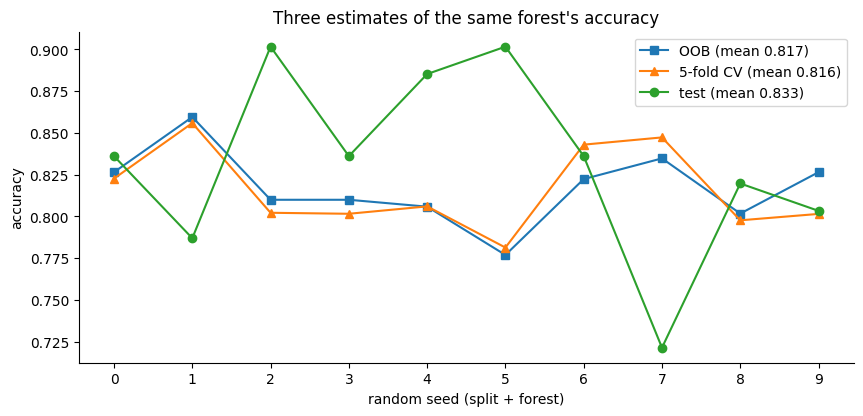

In [10]:
plt.figure(figsize=(10, 4.3))
for col, mk in zip(est.columns, ['s', '^', 'o']):
    plt.plot(est.index, est[col], mk + '-', label=f'{col} (mean {est[col].mean():.3f})')
plt.xticks(est.index)
plt.xlabel('random seed (split + forest)')
plt.ylabel('accuracy')
plt.title('Three estimates of the same forest\'s accuracy')
plt.legend()
plt.show()

**What we see:**
- The **OOB score and 5-fold CV agree closely** on every seed (means 0.817 and 0.816). OOB gives the CV answer
  **for free**, without the 5 extra trainings.
- The **test accuracy jumps around much more** (from 0.721 to 0.902, standard deviation 0.056 vs about 0.02 for
  OOB and CV), because it is based on only 61 patients.
- So on small datasets the OOB score is often a *more stable* estimate than a single small test split.

---
## Key takeaways
- Each tree's bootstrap sample leaves out about **36.8%** of the rows ($e^{-1}$): its **out-of-bag** rows.
- `oob_score=True` → `oob_score_`: every training row is predicted only by the trees that never saw it.
- The OOB score is a **free validation score**: no validation set, no extra training.
- It behaves like cross-validation; any single number on 300 rows is noisy, so do not over-read small differences.
- You need enough trees (here ≥ 15) so that every row is out-of-bag for some trees.

## 🧠 Quick check

<details><summary>1. Why is about 37% of the data out-of-bag for each tree?</summary>

A row is missed in one draw with probability 1 − 1/n, so it is missed in all n draws with probability (1 − 1/n)ⁿ ≈ e⁻¹ ≈ 0.368.
</details>

<details><summary>2. Which trees are used to predict a training row for the OOB score?</summary>

Only the trees whose bootstrap sample did not contain that row (about 37% of the trees).
</details>

<details><summary>3. Can you use the OOB score if <code>bootstrap=False</code>?</summary>

No. Without bootstrap every tree sees every row, so there are no out-of-bag rows (scikit-learn raises an error).
</details>

<details><summary>4. When is the OOB score especially useful?</summary>

On small datasets (you do not want to sacrifice rows for a validation set) and when training is expensive (no extra fits like k-fold CV).
</details>

➡️ **Next:** `05-feature-importance.ipynb`: how `feature_importances_` is calculated, and its pitfalls.